In [2]:
from utils_PI import TrajectorySegments , DecoderMLE
import numpy as np
import matplotlib.pyplot as plt


# testing if it works 

In [90]:
rat2_traj = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='light')
segments = rat2_traj.segments

In [91]:
rat2_decode = DecoderMLE(RAT_ID=2 , LIGHTING="light")


In [92]:
decoded ,  posteriors, K, window_edges =  rat2_decode.decode_segment_bayes_uniform(
    segment=segments[2] , dt_decode=0.05 )


In [111]:
decoded_adaptive = rat2_decode.decode_segment_adaptive(segments[34] , dist_step=1)

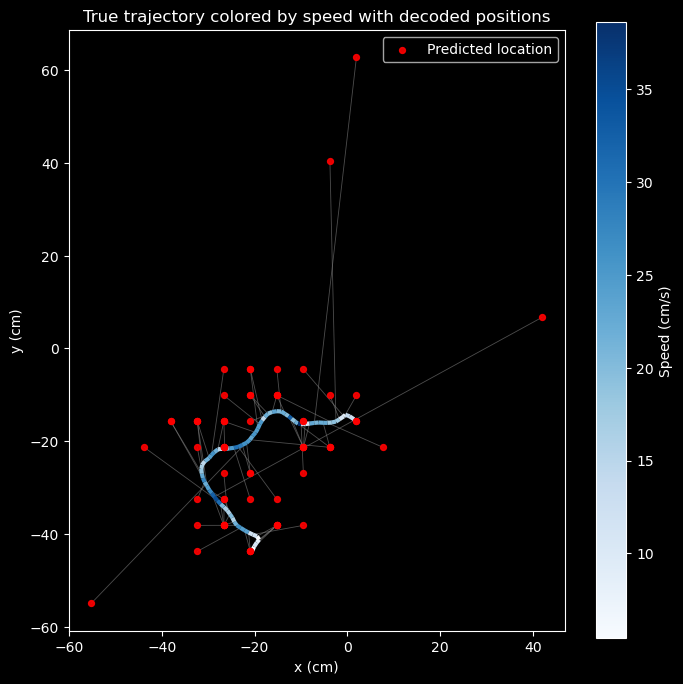

In [ ]:
rat2_decode.plot_comparitive_plot(decoded_adaptive)
# plot the stopping points 
# parametrs decode 
# cosine poplulation normal meurons 
#  change between the neyrons, see speed and tuening changing the error 
# dis similaryty of neyar data 

Note about the speed I have access to. Because it is going to be a smaller frequency that I am looking at the decoding compared to the recoreded data, and the instantnoius speed that I have as V, Nop matter how I make the plot, I have an interpolated speed. 

In [20]:
segment_v   = rat2_decode.segment_velocity(decoded , segments[0] , mod= 'inter')
segment_err = rat2_decode.decoding_error(decoded)

In [ ]:
plot_error_velocity(segments , rat2_decode , dt_decode=0.05)

## find the best dist_step

Average distance per segment: 23.26 cm
Total distance across all segments: 8210.69 cm


(array([ 86., 107.,  60.,  43.,  24.,  17.,   5.,   4.,   4.,   3.]),
 array([ 3.17250158, 11.75167425, 20.33084693, 28.91001961, 37.48919229,
        46.06836496, 54.64753764, 63.22671032, 71.805883  , 80.38505567,
        88.96422835]),
 <BarContainer object of 10 artists>)

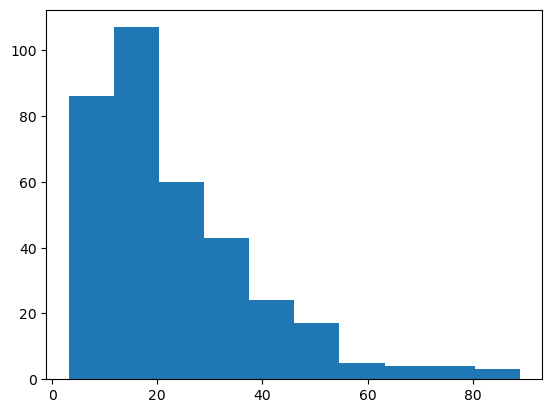

In [88]:
def calculate_segment_distances(segments, x, y):
    segment_lengths = []

    for seg in segments:
        s, e = int(seg[0]), int(seg[1])
        seg_x = x[s:e]
        seg_y = y[s:e]

        dx = np.diff(seg_x)
        dy = np.diff(seg_y)
        
        step_distances = np.sqrt(dx**2 + dy**2)
        
        # Total distance for this segment
        total_dist = np.nansum(step_distances)
        segment_lengths.append(total_dist)
        
    return np.array(segment_lengths)

distances = calculate_segment_distances(segments, rat2_decode.x, rat2_decode.y)

avg_dist = np.mean(distances)
std_dist = np.std(distances)

print(f"Average distance per segment: {avg_dist:.2f} cm")
print(f"Total distance across all segments: {np.sum(distances):.2f} cm")
plt.hist(distances)

In [97]:
steps = [1, 2, 3, 4 , 5, 6 , 7, 8, 9 ,10 ,15, 20, 25]
def find_best_dist_step(segments , rat_ , steps):
    for dist_step in steps:
        all_err = []
        empty_segments = 0
        for seg in segments:
            decoded = rat_.decode_segment_adaptive(seg , dist_step = dist_step)
            try:
                segment_err = rat_.decoding_error(decoded)
            except:
                empty_segments += 1
                continue
            all_err.extend(segment_err)

        all_err = np.array(all_err)
        print(f'mean error for {dist_step} cm distance is: {np.mean(all_err)} with {empty_segments} empty_segments ')

In [109]:
find_best_dist_step(segments , rat2_decode , steps)

mean error for 1 cm distance is: 11.991740074290606 with 0 empty_segments 
mean error for 2 cm distance is: 8.075806281871014 with 0 empty_segments 
mean error for 3 cm distance is: 7.006304545573195 with 0 empty_segments 
mean error for 4 cm distance is: 6.670054834372858 with 3 empty_segments 
mean error for 5 cm distance is: 6.474830613605153 with 8 empty_segments 
mean error for 6 cm distance is: 6.264164632492427 with 24 empty_segments 
mean error for 7 cm distance is: 6.123781229169844 with 32 empty_segments 
mean error for 8 cm distance is: 6.092134382650476 with 43 empty_segments 
mean error for 9 cm distance is: 6.0640422924384785 with 57 empty_segments 
mean error for 10 cm distance is: 6.059812541145946 with 65 empty_segments 
mean error for 15 cm distance is: 5.655924003971557 with 131 empty_segments 
mean error for 20 cm distance is: 6.008624277409414 with 189 empty_segments 
mean error for 25 cm distance is: 6.254701470875145 with 231 empty_segments 


# error vs V plots 

In [183]:
def plot_error_velocity(segments , rat_decode , dt_decode=0.05 ,dist_step=5.0 ,adaptive = False , rat = '2 light') :
    all_v = []
    all_err = []

    for seg in segments:
        # Run the decoder for each segment
        if adaptive:
            decoded = rat_decode.decode_segment_adaptive(seg , dist_step = dist_step)
        else:
            decoded ,  posteriors, K, window_edges =  rat_decode.decode_segment_bayes_uniform(
                segment=seg , dt_decode=dt_decode )

        try:
            segment_v   = rat_decode.segment_velocity(decoded , seg , mod= 'inter')
        except:
            continue
        segment_err = rat_decode.decoding_error(decoded)
        all_v.extend(segment_v)
        all_err.extend(segment_err)

    all_v = np.array(all_v)
    all_err = np.array(all_err)

    # 2. Define Velocity Bins (starting from 3 cm/s as requested)
    v_min, v_max = 3, 45
    n_bins = 15
    v_bins = np.linspace(v_min, v_max, n_bins + 1)
    bin_centers = 0.5 * (v_bins[:-1] + v_bins[1:])

    # 3. Calculate Stats per Bin
    bin_means = []
    bin_counts = []
    bin_sem = []

    for i in range(len(v_bins)-1):
        mask = (all_v >= v_bins[i]) & (all_v < v_bins[i+1])
        n_samples = np.sum(mask)
        bin_counts.append(n_samples)
        
        if n_samples > 0:
            bin_means.append(np.mean(all_err[mask]))
            bin_sem.append(np.std(all_err[mask]) / np.sqrt(n_samples))
        else:
            bin_means.append(np.nan)
            bin_sem.append(np.nan)

    # 4. Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Mean Error (Primary Y-axis)
    ax1.set_xlabel('Velocity (cm/s)', fontsize=12)
    ax1.set_ylabel('Mean Decoding Error (cm)', color='tab:blue', fontsize=12)
    lns1 = ax1.errorbar(bin_centers, bin_means, yerr=bin_sem, fmt='-o', 
                        color='tab:blue', capsize=4, lw=2, label='Mean Error')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)

    # Plot Sample Counts (Secondary Y-axis)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Number of Windows (Sample Count)', color='tab:gray', fontsize=12)
    lns2 = ax2.bar(bin_centers, bin_counts, width=(v_max-v_min)/n_bins * 0.8, 
                alpha=0.2, color='tab:gray', label='Bin Count')
    ax2.tick_params(axis='y', labelcolor='tab:gray')

    plt.title(f'Decoding Performance & Data Density vs. Velocity rat {rat}', fontsize=14)
    fig.tight_layout()
    plt.show()



def get_pvs_across_segments(segments , rat_decode , dist_step=5.0):
    all_pvs = []
    all_errors = []
    all_v = []

    cell_ids = list(rat_decode.spikes_by_cell.keys())

    for seg in segments:
        # Use our adaptive window edges
        s, e = int(seg[0]), int(seg[1])
        window_edges = rat_decode.get_distance_based_windows(rat_decode.t[s:e], rat_decode.x[s:e], rat_decode.y[s:e], dist_step)
        
        dec = rat_decode.decode_segment_adaptive(seg , dist_step = dist_step)
        
        if len(dec) == 0: continue
            
        # 2. Calculate time passed since segment start
        t_start = seg[2] # t[s] from your segment list
        relative_t = dec[:, 0] - t_start
        
        # 3. Calculate absolute error
        dx = dec[:, 1] - dec[:, 3]
        dy = dec[:, 2] - dec[:, 4]
        err = np.sqrt(dx**2 + dy**2)
        
        all_errors.extend(err)


        for w in range(len(window_edges) - 1):
            t_start, t_end = window_edges[w], window_edges[w+1]
            dt = t_end - t_start
            if dt <= 0: continue
            
            # 1. Calculate Population Vector Strength (Total Spikes / dt)
            total_spikes = 0
            for cid in cell_ids:
                spks = rat_decode.spikes_by_cell[cid]
                total_spikes += np.sum((spks >= t_start) & (spks < t_end))
            
            pvs_hz = total_spikes / dt # Population Strength in Hz
            # print(total_spikes)
            
            # 2. Get Error and Velocity for this window
            t_mid = (t_start + t_end) / 2
            # x_true = np.interp(t_mid, t, x)
            # y_true = np.interp(t_mid, t, y)
            
            # (Assuming you have 'decoded' results or calculating MAP here)
            # For this example, let's just store the PVS and Velocity
            v_mid = np.interp(t_mid, rat_decode.t, rat_decode.v) 
            
            all_pvs.append(pvs_hz)
            all_v.append(v_mid)

    return np.array(all_v), np.array(all_pvs) , np.array(all_errors)

In [182]:
all_v.shape , all_pvs.shape, all_errors.shape, len(segments)

((1473,), (1473,), (1473,), 353)

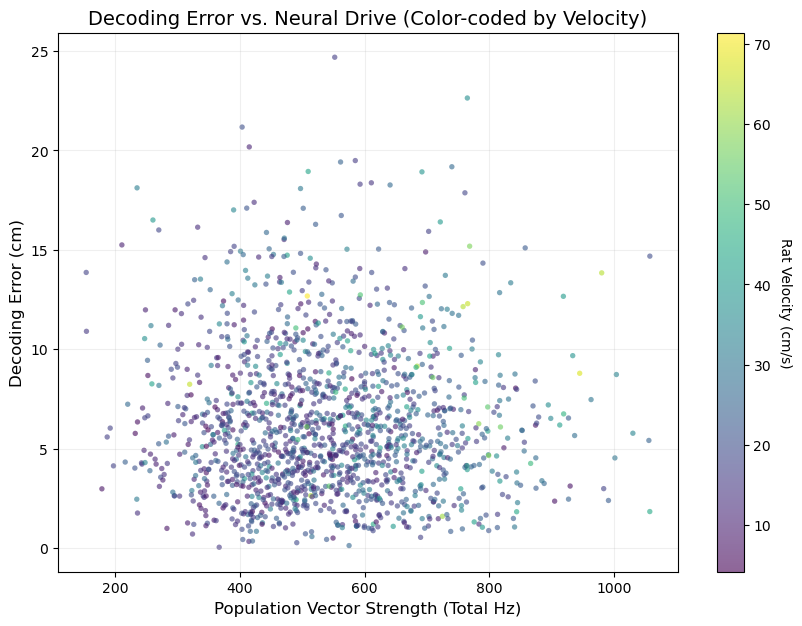

In [184]:
all_v , all_pvs, all_errors = get_pvs_across_segments(segments, rat2_decode, dist_step=5)
mask = np.where(all_errors < 30)
v_masked = all_v[mask]
pvs_masked = all_pvs[mask]
err_masked = all_errors[mask]

plt.figure(figsize=(10, 7))

# 2. Scatter plot with color coding (c) and a colorbar
sc = plt.scatter(pvs_masked, err_masked, 
                 c=v_masked, cmap='viridis', 
                 alpha=0.6, s=15, edgecolor='none')

# 3. Add formatting and labels
plt.xlabel('Population Vector Strength (Total Hz)', fontsize=12)
plt.ylabel('Decoding Error (cm)', fontsize=12)
plt.title('Decoding Error vs. Neural Drive (Color-coded by Velocity)', fontsize=14)

# 4. Add the colorbar to define what the colors mean
cbar = plt.colorbar(sc)
cbar.set_label('Rat Velocity (cm/s)', rotation=270, labelpad=15)

plt.grid(alpha=0.2)
plt.show()

The adaptive window will help at High Speed: The window becomes very short (e.g., 80 ms). This prevents the rat from moving across multiple grid "fields" within a single window, which would otherwise confuse the decoder.

If the rat happened to run through a clear grid peak during those specific high-speed moments, the error drops; if it ran through a "silent" gap between fields, the error spikes.

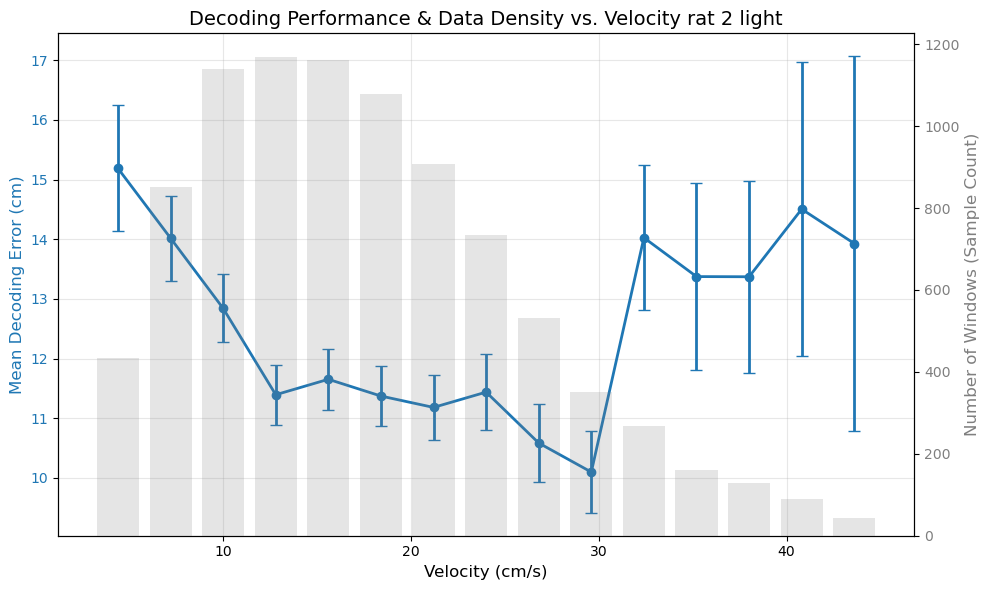

In [190]:
plot_error_velocity(segments , rat2_decode , dt_decode=0.05 , dist_step=5.0 , adaptive=False , rat='2 light')

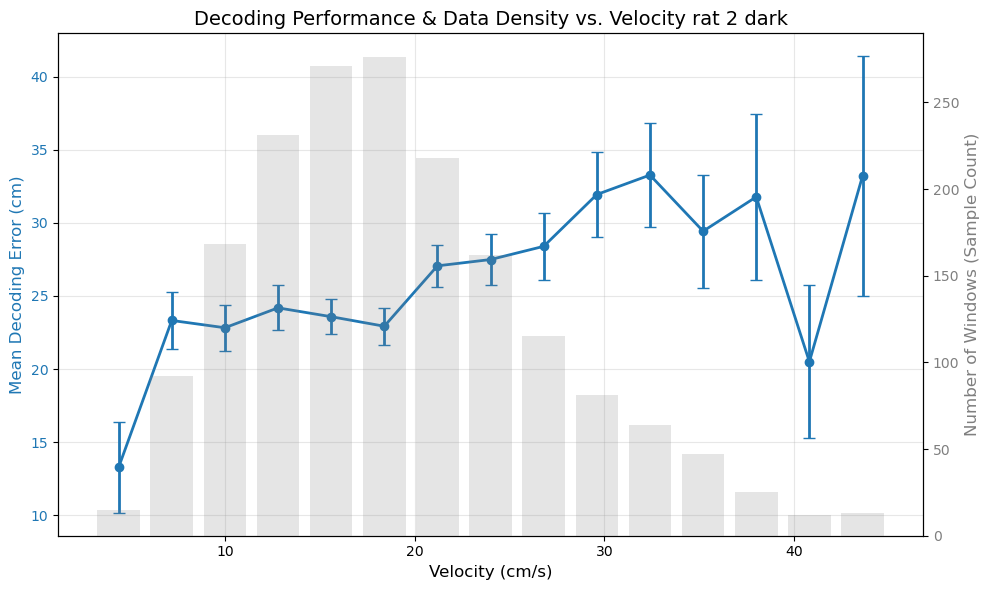

In [144]:
rat2dark_traj = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='dark')
segments_dark2 = rat2dark_traj.segments
rat2dark_decode = DecoderMLE(RAT_ID=2 , LIGHTING="dark")
plot_error_velocity(segments_dark2 , rat2dark_decode ,  dist_step=6.0, adaptive=True , rat='2 dark')


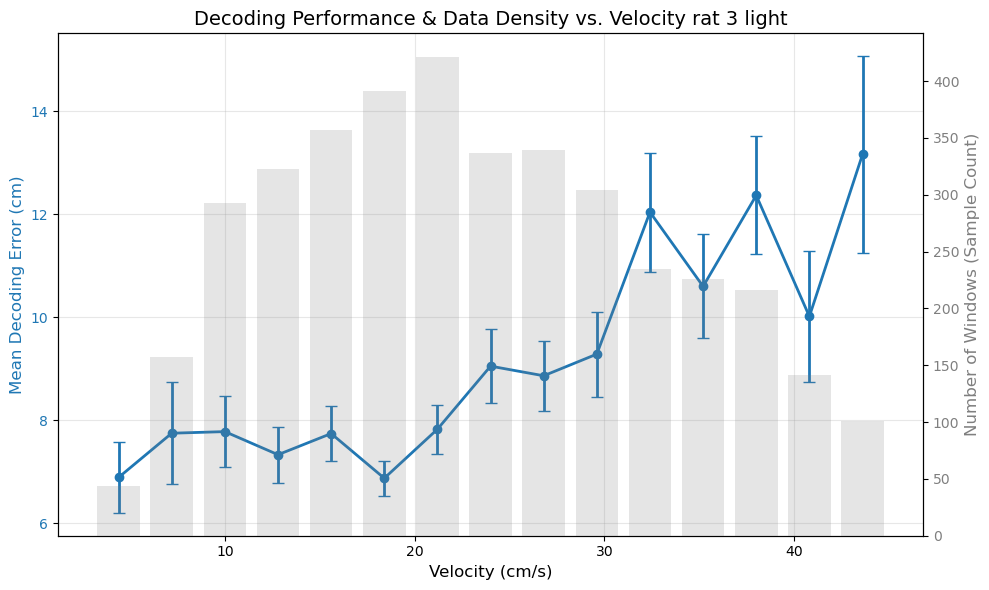

In [145]:
rat3 = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=3 , LIGHTING='light')
segments_light3 = rat3.segments
rat3light_decode = DecoderMLE(RAT_ID=3 , LIGHTING="light")
plot_error_velocity(segments_light3 , rat3light_decode ,  dist_step=2.0, adaptive=True , rat='3 light')


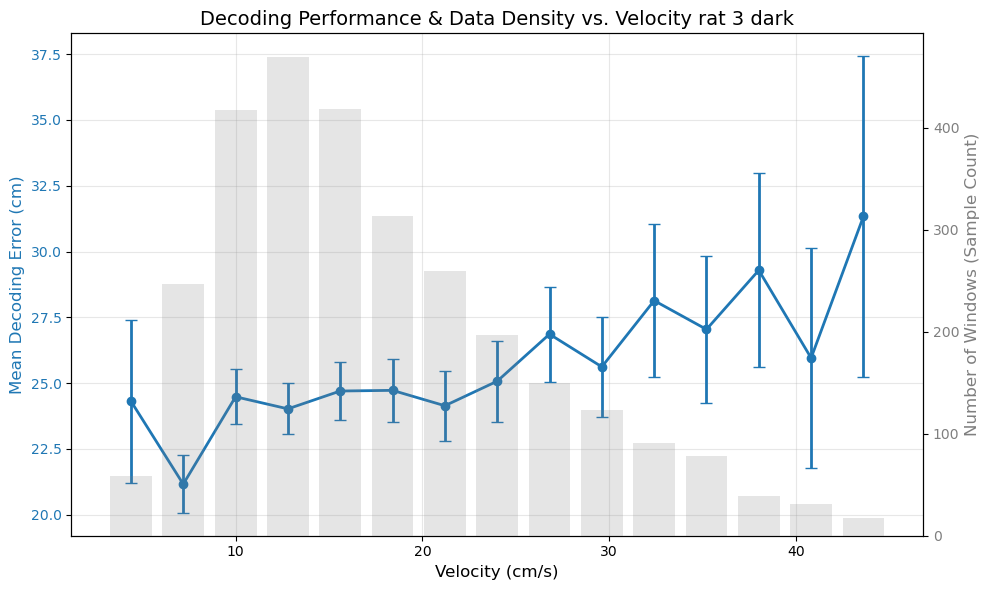

In [148]:
rat3_dark = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=3 , LIGHTING='dark')
segments_dark3 = rat3_dark.segments
rat3dark_decode = DecoderMLE(RAT_ID=3 , LIGHTING="dark")
plot_error_velocity(segments_dark3 , rat3dark_decode ,  dist_step=3.0, adaptive=True , rat='3 dark')


# Error vs Head direction plots 

## Head direction

In [24]:
def get_error_vs_hd_change(segments, rat_decode, dist_step=5.0):
    all_hd_changes = []
    all_errors = []
    
    # 1. Calculate global angular velocity (rad/s)
    # Using np.unwrap or manual circular difference
    hd = rat_decode.hd
    t = rat_decode.t
    
    # Calculate circular difference: (angle_t1 - angle_t0 + pi) % 2pi - pi
    d_hd = np.diff(hd)
    d_hd = (d_hd + np.pi) % (2 * np.pi) - np.pi
    
    dt_hd = np.diff(t)
    
    # Angular speed in radians per second
    ang_vel = np.abs(d_hd / dt_hd)
    # Pad to match length of t
    ang_vel = np.insert(ang_vel, 0, ang_vel[0])

    for seg in segments:
        # Decode segment
        dec = rat_decode.decode_segment_adaptive(seg, dist_step=dist_step)
        if len(dec) == 0: continue

        # 2. Get angular velocity at decoding midpoints
        # Interpolate the angular velocity at the time of each decoding window
        hd_change_at_windows = np.interp(dec[:, 0], t, ang_vel)
        
        # 3. Calculate error
        err = np.sqrt((dec[:, 1] - dec[:, 3])**2 + (dec[:, 2] - dec[:, 4])**2)
        
        all_hd_changes.extend(hd_change_at_windows)
        all_errors.extend(err)
        
    return np.array(all_hd_changes), np.array(all_errors)



def plot_hd_change_vs_error(segments, rat_decode, dist_step=5.0):
    hd_vel, err_vals = get_error_vs_hd_change(segments, rat_decode, dist_step)

    # Binning (e.g., from 0 to 10 rad/s)
    bins = np.linspace(0, np.percentile(hd_vel, 98), 30)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    bin_means, bin_sem, bin_counts = [], [], []

    for i in range(len(bins)-1):
        mask = (hd_vel >= bins[i]) & (hd_vel < bins[i+1])
        count = np.sum(mask)
        bin_counts.append(count)
        if count > 5: # Threshold to avoid noisy low-sample bins
            bin_means.append(np.mean(err_vals[mask]))
            bin_sem.append(np.std(err_vals[mask]) / np.sqrt(count))
        else:
            bin_means.append(np.nan); bin_sem.append(np.nan)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Error Line
    ax1.errorbar(bin_centers, bin_means, yerr=bin_sem, fmt='-o', color='crimson', label='Mean Error')
    ax1.set_xlabel('Angular Velocity (rad/s)', fontsize=12)
    ax1.set_ylabel('Mean Decoding Error (cm)', color='crimson', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='crimson')

    # Sample Count Bars
    ax2 = ax1.twinx()
    ax2.bar(bin_centers, bin_counts, width=(bins[1]-bins[0])*0.8, alpha=0.15, color='gray')
    ax2.set_ylabel('Sample Count', color='gray')
    
    plt.title('Decoding Error vs. Rate of Head Direction Change')
    plt.show()

In [44]:
RAT_ID = 2

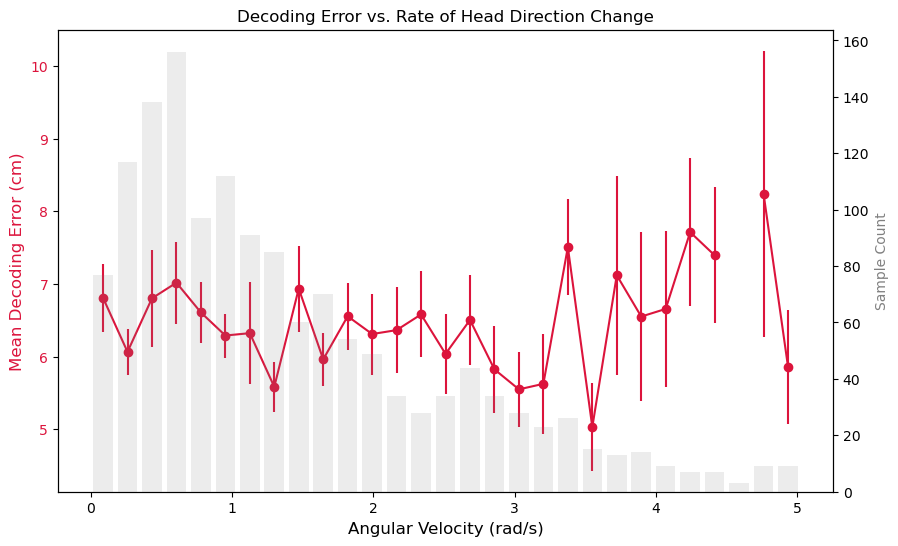

In [45]:

rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='light')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID, LIGHTING="light")
plot_hd_change_vs_error(segments_, rat_decode)

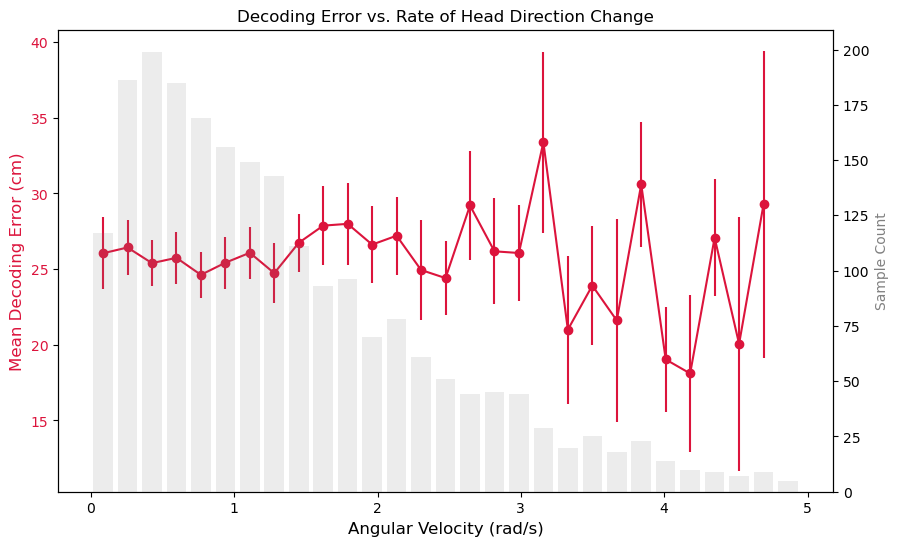

In [46]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=RAT_ID , LIGHTING='dark')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID , LIGHTING="dark")
plot_hd_change_vs_error(segments_, rat_decode)

## Heading direction

In [ ]:
def get_error_vs_movement_angular_velocity(segments, rat_decode, dist_step=5.0):
    all_ang_vel = []
    all_errors = []
    
    # 1. Calculate Movement Angle from X, Y
    dx_pos = np.diff(rat_decode.x)
    dy_pos = np.diff(rat_decode.y)
    # This gives us the angle of the velocity vector
    move_angle = np.arctan2(dy_pos, dx_pos)
    
    # 2. Calculate Angular Velocity (rate of change of movement direction)
    # Circular difference to handle -pi to pi jump
    d_angle = np.diff(move_angle)
    d_angle = (d_angle + np.pi) % (2 * np.pi) - np.pi
    
    dt = np.diff(rat_decode.t[:-1]) # Match lengths
    ang_vel = np.abs(d_angle / dt)
    
    # Pad to match original time array length
    ang_vel = np.pad(ang_vel, (2, 0), mode='edge') 

    for seg in segments:
        dec = rat_decode.decode_segment_adaptive(seg, dist_step=dist_step)
        if len(dec) == 0: continue

        # Interpolate angular velocity at decoding midpoints
        vel_at_windows = np.interp(dec[:, 0], rat_decode.t, ang_vel)
        
        # Calculate Euclidean Error
        err = np.sqrt((dec[:, 1] - dec[:, 3])**2 + (dec[:, 2] - dec[:, 4])**2)
        
        all_ang_vel.extend(vel_at_windows)
        all_errors.extend(err)
        
    return np.array(all_ang_vel), np.array(all_errors)



def plot_movement_turning_vs_error(segments, rat_decode, dist_step=5.0):
    ang_vel, err_vals = get_error_vs_movement_angular_velocity(segments, rat_decode, dist_step)

    # Binning (Radians per second)
    bins = np.linspace(0, np.percentile(ang_vel, 95), 15)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    means, sems, counts = [], [], []

    for i in range(len(bins)-1):
        mask = (ang_vel >= bins[i]) & (ang_vel < bins[i+1])
        n = np.sum(mask)
        counts.append(n)
        if n > 10:
            means.append(np.mean(err_vals[mask]))
            sems.append(np.std(err_vals[mask]) / np.sqrt(n))
        else:
            means.append(np.nan); sems.append(np.nan)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Error Line (Primary)
    ax1.errorbar(bin_centers, means, yerr=sems, fmt='-o', color='teal', lw=2, label='Decoding Error')
    ax1.set_xlabel('Angular Velocity of Movement (rad/s)', fontsize=12)
    ax1.set_ylabel('Mean Decoding Error (cm)', color='teal', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='teal')

    # Sample Count (Secondary)
    ax2 = ax1.twinx()
    ax2.bar(bin_centers, counts, width=(bins[1]-bins[0])*0.7, alpha=0.1, color='gray')
    ax2.set_ylabel('Sample Count', color='gray')

    plt.title('Decoding Error vs. Path Curvature (Change in Movement Direction)')
    plt.show()

In [113]:
RAT_ID = 1
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='light')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID, LIGHTING="light")
ang_vel, err_vals = get_error_vs_hd_change(segments_, rat_decode, dist_step =1)


Text(0.5, 1.0, 'Density Mapping: Turning vs. Error')

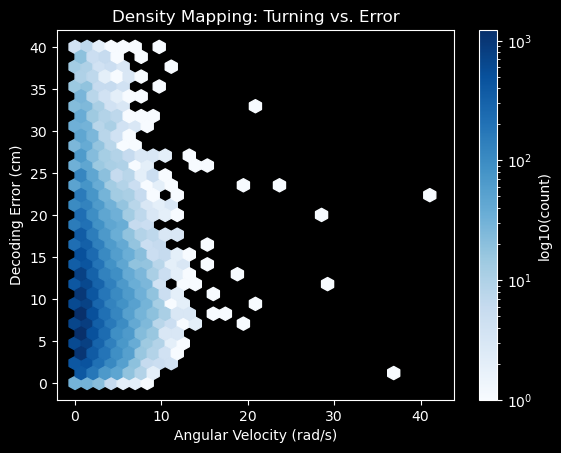

In [114]:
mask = err_vals < 40
plt.hexbin(ang_vel[mask], err_vals[mask], gridsize=30, cmap='Blues', bins='log')#'log')
plt.colorbar(label='log10(count)')
plt.xlabel('Angular Velocity (rad/s)')
plt.ylabel('Decoding Error (cm)')
plt.title('Density Mapping: Turning vs. Error')

In [115]:
RAT_ID = 1
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='dark')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID, LIGHTING="dark")
ang_vel, err_vals = get_error_vs_hd_change(segments_, rat_decode, dist_step =1)


Text(0.5, 1.0, 'Density Mapping: Turning vs. Error')

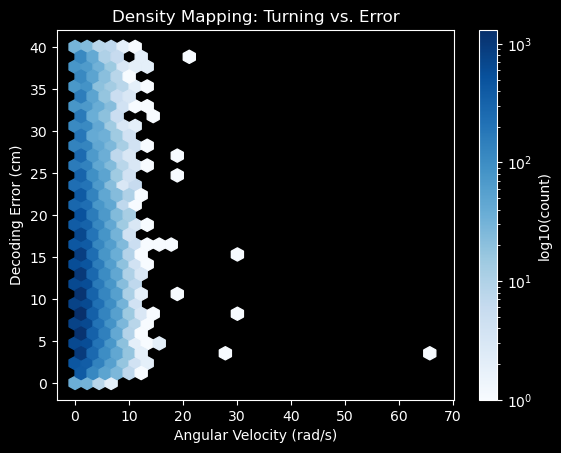

In [116]:
mask = err_vals < 40
plt.hexbin(ang_vel[mask], err_vals[mask], gridsize=30, cmap='Blues', bins='log')#'log')
plt.colorbar(label='log10(count)')
plt.xlabel('Angular Velocity (rad/s)')
plt.ylabel('Decoding Error (cm)')
plt.title('Density Mapping: Turning vs. Error')

## linear vs angular

In [60]:
from scipy.stats import binned_statistic_2d
def get_velocity_interaction_data(segments, rat_decode, dist_step=5.0):
    all_v = []
    all_omega = [] # Angular velocity
    all_err = []

    # Calculate global angular velocity once
    hd = rat_decode.hd
    t = rat_decode.t
    d_hd = np.diff(hd)
    d_hd = (d_hd + np.pi) % (2 * np.pi) - np.pi
    dt_hd = np.diff(t)
    ang_vel_global = np.insert(np.abs(d_hd / dt_hd), 0, 0)

    for seg in segments:
        # 1. Decode
        dec = rat_decode.decode_segment_adaptive(seg, dist_step=dist_step)
        if len(dec) == 0: continue

        # 2. Get Linear Velocity at windows
        try:
            v_win = rat_decode.segment_velocity(dec, seg, mod='inter')
        except: continue

        # 3. Get Angular Velocity at windows
        omega_win = np.interp(dec[:, 0], t, ang_vel_global)

        # 4. Get Error
        err_win = np.sqrt((dec[:, 1] - dec[:, 3])**2 + (dec[:, 2] - dec[:, 4])**2)

        all_v.extend(v_win)
        all_omega.extend(omega_win)
        all_err.extend(err_win)

    return np.array(all_v), np.array(all_omega), np.array(all_err)

def plot_error_2d_velocity_grid(all_v, all_omega, all_err):
    # Filter for reasonable ranges (excluding extreme outliers for cleaner plot)
    mask = (all_v < 50) & (all_omega < 10) & (all_err < 30)
    v, omega, err = all_v[mask], all_omega[mask], all_err[mask]

    # Calculate Mean Error in 2D bins
    # Increase bins for more detail, decrease for more stability
    statistic, x_edges, y_edges, binnumber = binned_statistic_2d(
        v, omega, err, statistic='mean', bins=[30, 30]
    )

    # Calculate Counts to mask low-data areas
    counts, _, _ , _ = binned_statistic_2d(v, omega, None, statistic='count', bins=[30, 30])
    statistic[counts < 5] = np.nan  # Hide bins with very few samples

    plt.figure(figsize=(10, 8))
    
    # Plotting the heatmap
    im = plt.imshow(statistic.T, origin='lower', aspect='auto',
                    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
                    cmap='plasma') # 'magma' is great for highlighting high error
    
    plt.colorbar(im, label='Mean Decoding Error (cm)')
    plt.xlabel('Linear Velocity (cm/s)', fontsize=12)
    plt.ylabel('Angular Velocity (rad/s)', fontsize=12)
    plt.title('Decoding Error Interaction: Speed vs. Turning', fontsize=14)
    
    # Overlay individual data points as subtle dots to show density
    # plt.scatter(v, omega, c='white', s=1, alpha=0.1)
    
    plt.show()

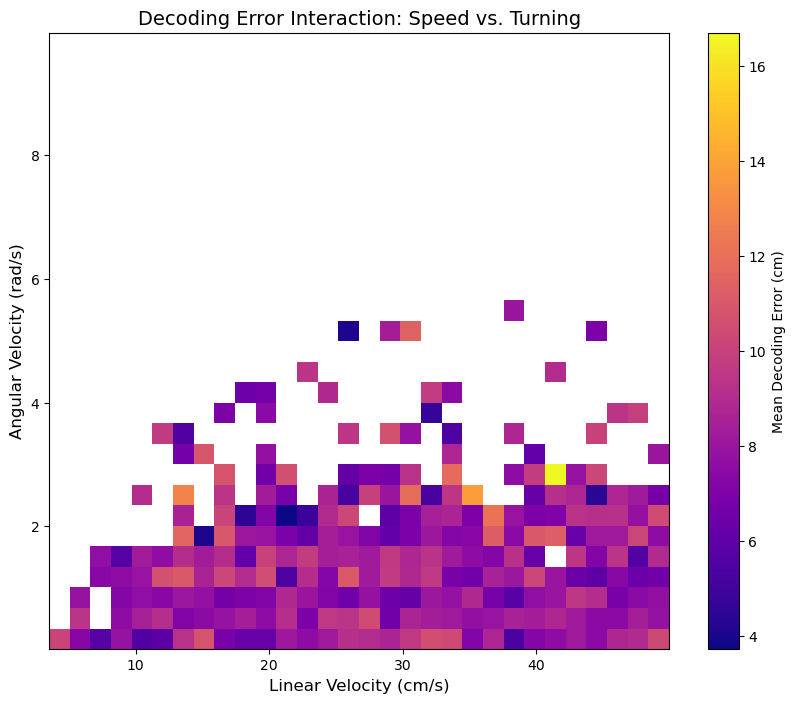

In [71]:
RAT_ID = 1
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='light')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID, LIGHTING="light")
ang_vel, err_vals = get_error_vs_hd_change(segments_, rat_decode, 5)

all_v , all_omega , all_err = get_velocity_interaction_data(segments_, rat_decode, dist_step=1.0)
plot_error_2d_velocity_grid(all_v, all_omega, all_err)

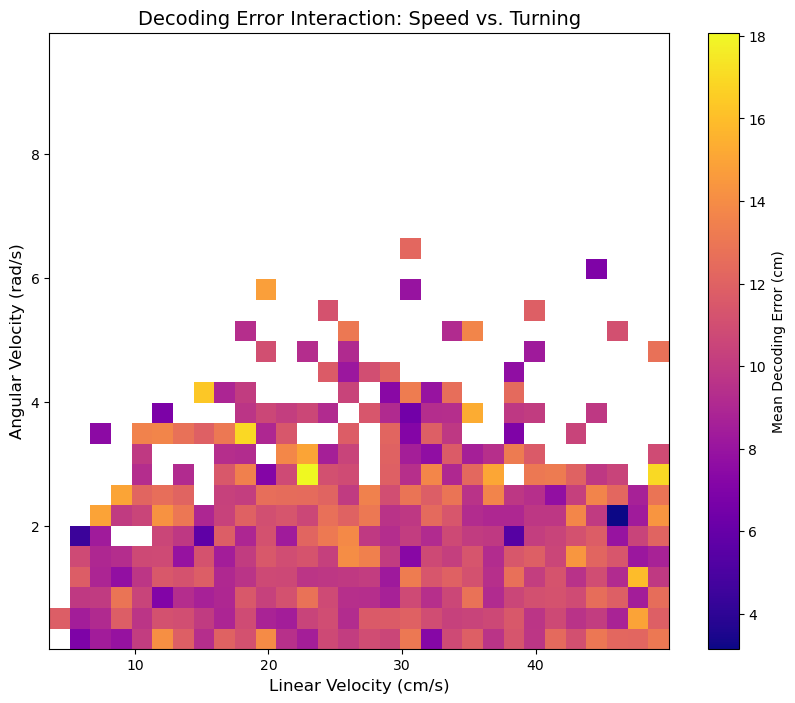

In [72]:
RAT_ID = 1
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='dark')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID, LIGHTING="dark")
ang_vel, err_vals = get_error_vs_hd_change(segments_, rat_decode, 5)

all_v , all_omega , all_err = get_velocity_interaction_data(segments_, rat_decode, dist_step=5.0)
plot_error_2d_velocity_grid(all_v, all_omega, all_err)

## Population firiing at turns

In [80]:
def get_pvs_vs_angular_velocity(segments, rat_decode, dist_step=5.0):
    all_pvs = []
    all_omega = [] # Angular Velocity
    all_v = []     # Linear Velocity (useful for color-coding)

    # 1. Pre-calculate global Angular Velocity (rad/s)
    hd = rat_decode.hd
    t = rat_decode.t
    d_hd = np.diff(hd)
    d_hd = (d_hd + np.pi) % (2 * np.pi) - np.pi
    dt_hd = np.diff(t)
    # Using np.abs because we care about the speed of the turn, not the direction
    ang_vel_global = np.insert(np.abs(d_hd / dt_hd), 0, 0)

    cell_ids = list(rat_decode.spikes_by_cell.keys())

    for seg in segments:
        # 2. Get the decoding windows for this segment
        dec = rat_decode.decode_segment_adaptive(seg, dist_step=dist_step)
        if len(dec) == 0: continue

        for row in dec:
            t_mid = row[0]
            # In adaptive decoding, we need the actual window duration (dt) to get Hz
            # If your 'dec' doesn't store dt, we estimate based on local linear velocity
            v_inst = np.interp(t_mid, t, rat_decode.v)
            dt_est = dist_step / (v_inst + 1e-6) 

            # 3. Calculate PVS (Total Spikes / dt)
            t_start = t_mid - (dt_est / 2)
            t_end = t_mid + (dt_est / 2)
            
            total_spikes = 0
            for cid in cell_ids:
                spks = rat_decode.spikes_by_cell[cid]
                total_spikes += np.sum((spks >= t_start) & (spks < t_end))
            
            pvs_hz = total_spikes / dt_est
            
            # 4. Get Angular Velocity at this window
            omega_inst = np.interp(t_mid, t, ang_vel_global)

            all_pvs.append(pvs_hz)
            all_omega.append(omega_inst)
            all_v.append(v_inst)

    return np.array(all_pvs), np.array(all_omega), np.array(all_v)




In [ ]:
RAT_ID = 1
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='light')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID, LIGHTING="light")
pvs, omega, v = get_pvs_vs_angular_velocity(segments_, rat_decode , dist_step = 1)

In [121]:
RAT_ID = 1
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='light')
segments_ = rat.segments
len(segments_)

704

/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_1270/1196240641.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


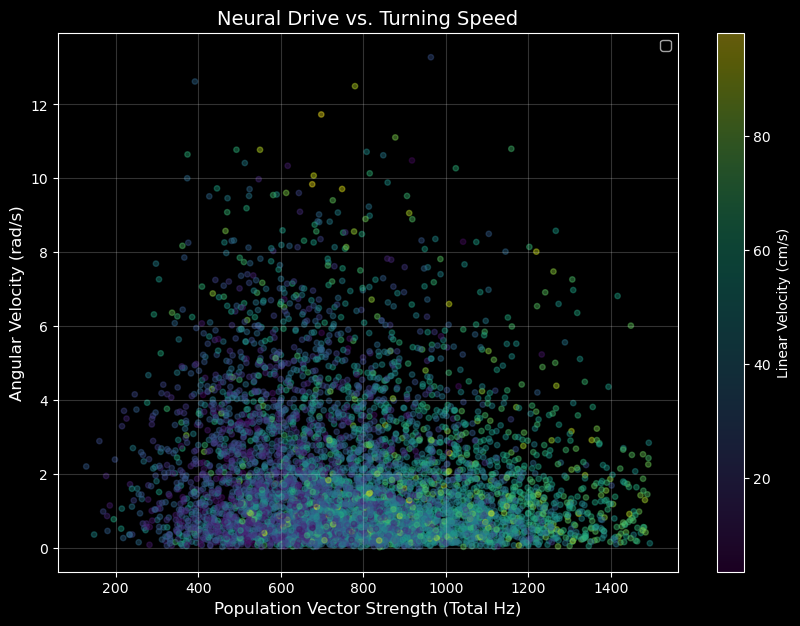

In [89]:
# Filter outliers for a cleaner plot
mask = (pvs < 1500) & (omega < 15) 
# plt.style.use('dark_background')
plt.figure(figsize=(10, 7))
sc = plt.scatter(pvs[mask], omega[mask], c=v[mask], cmap='viridis', alpha=0.4, s=15)

# Add a trend line to see the general relationship
# from scipy.stats import linregress
# slope, intercept, r_val, p_val, std_err = linregress(pvs[mask], omega[mask])
# plt.plot(pvs[mask], slope*pvs[mask] + intercept, color='red', label=f'R={r_val:.2f}')

plt.colorbar(sc, label='Linear Velocity (cm/s)')
plt.xlabel('Population Vector Strength (Total Hz)', fontsize=12)
plt.ylabel('Angular Velocity (rad/s)', fontsize=12)
plt.title('Neural Drive vs. Turning Speed', fontsize=14)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [117]:
RAT_ID = 1
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='dark')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID, LIGHTING="dark")
pvs, omega, v = get_pvs_vs_angular_velocity(segments_, rat_decode , dist_step = 1)

In [120]:
RAT_ID = 1
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='dark')
segments_ = rat.segments
len(segments_)

901

/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_1270/3755311502.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


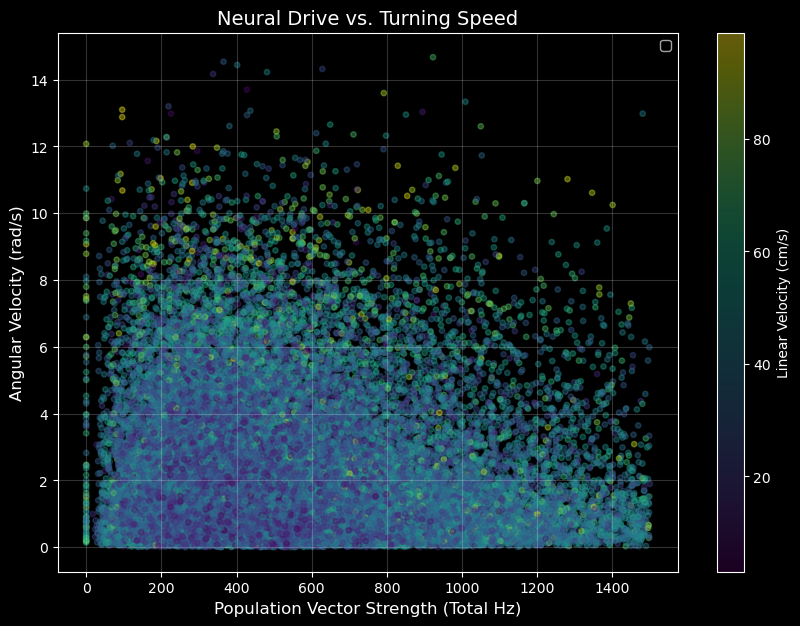

In [118]:
# Filter outliers for a cleaner plot
mask = (pvs < 1500) & (omega < 15) 
# plt.style.use('dark_background')
plt.figure(figsize=(10, 7))
sc = plt.scatter(pvs[mask], omega[mask], c=v[mask], cmap='viridis', alpha=0.4, s=15)

# Add a trend line to see the general relationship
# from scipy.stats import linregress
# slope, intercept, r_val, p_val, std_err = linregress(pvs[mask], omega[mask])
# plt.plot(pvs[mask], slope*pvs[mask] + intercept, color='red', label=f'R={r_val:.2f}')

plt.colorbar(sc, label='Linear Velocity (cm/s)')
plt.xlabel('Population Vector Strength (Total Hz)', fontsize=12)
plt.ylabel('Angular Velocity (rad/s)', fontsize=12)
plt.title('Neural Drive vs. Turning Speed', fontsize=14)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

## binned plots 

In [76]:
RAT_ID = 3

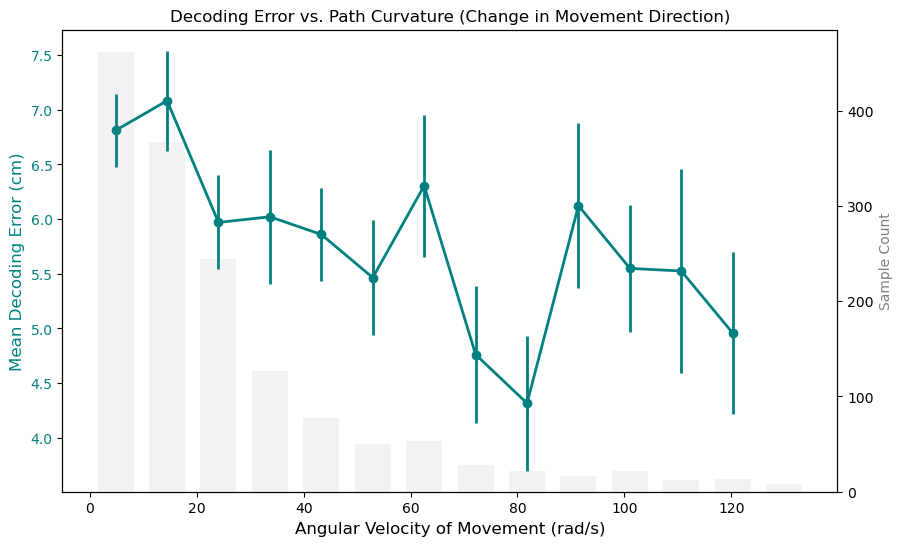

In [77]:

rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID= RAT_ID, LIGHTING='light')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID, LIGHTING="light")
plot_movement_turning_vs_error(segments_, rat_decode)

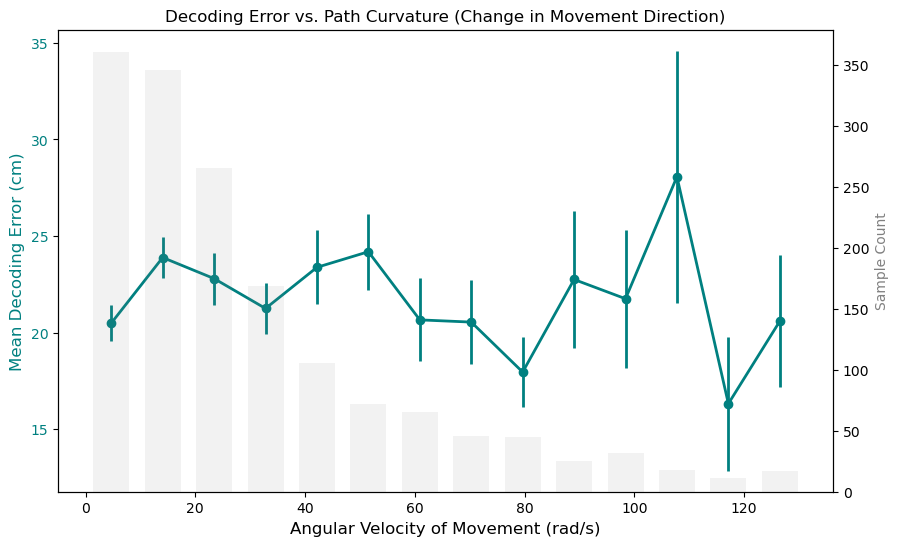

In [78]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=RAT_ID , LIGHTING='dark')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=RAT_ID , LIGHTING="dark")
plot_movement_turning_vs_error(segments_, rat_decode)

# elapsed time plots

In [188]:
def get_error_vs_time_passed(segments, rat_decode, dist_step=8.0):
    all_relative_times = []
    all_errors = []

    for seg in segments:
        # 1. Decode using our adaptive windowing
        dec = rat_decode.decode_segment_adaptive(seg , dist_step = dist_step)
        
        if len(dec) == 0: continue
            
        # 2. Calculate time passed since segment start
        t_start = seg[2] # t[s] from your segment list
        relative_t = dec[:, 0] - t_start
        
        # 3. Calculate absolute error
        dx = dec[:, 1] - dec[:, 3]
        dy = dec[:, 2] - dec[:, 4]
        err = np.sqrt(dx**2 + dy**2)
        
        all_relative_times.extend(relative_t)
        all_errors.extend(err)
        
    return np.array(all_relative_times), np.array(all_errors)

def plot_passed_time(segments, rat_decode, dist_step=8.0):
    rel_t, err_vals = get_error_vs_time_passed(segments, rat_decode , dist_step=dist_step)

    # Binning by time (e.g., every 1 second)
    t_bins = np.arange(0, np.max(rel_t), .4)
    bin_centers = 0.5 * (t_bins[:-1] + t_bins[1:])
    bin_means = []
    bin_sem = []

    for i in range(len(t_bins)-1):
        mask = (rel_t >= t_bins[i]) & (rel_t < t_bins[i+1])
        if np.any(mask):
            bin_means.append(np.mean(err_vals[mask]))
            bin_sem.append(np.std(err_vals[mask]) / np.sqrt(np.sum(mask)))
        else:
            bin_means.append(np.nan)
            bin_sem.append(np.nan)

    plt.figure(figsize=(9, 5))
    plt.errorbar(bin_centers, bin_means, yerr=bin_sem, fmt='-o', capsize=3, color='forestgreen')
    plt.xlabel('Time Passed in Segment (s)')
    plt.ylabel('Mean Decoding Error (cm)')
    plt.title('Decoding Stability Over Segment Duration')
    plt.grid(alpha=0.2)
    plt.show()

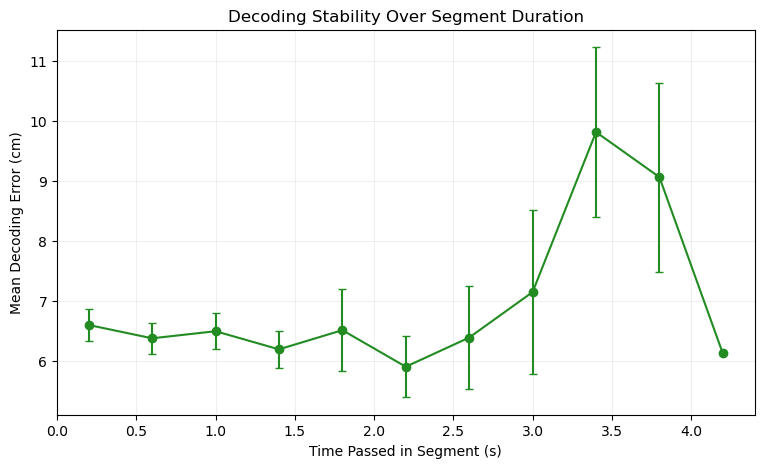

In [ ]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='light')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=2 , LIGHTING="light")
plot_passed_time(segments , rat_decode , dist_step=5)


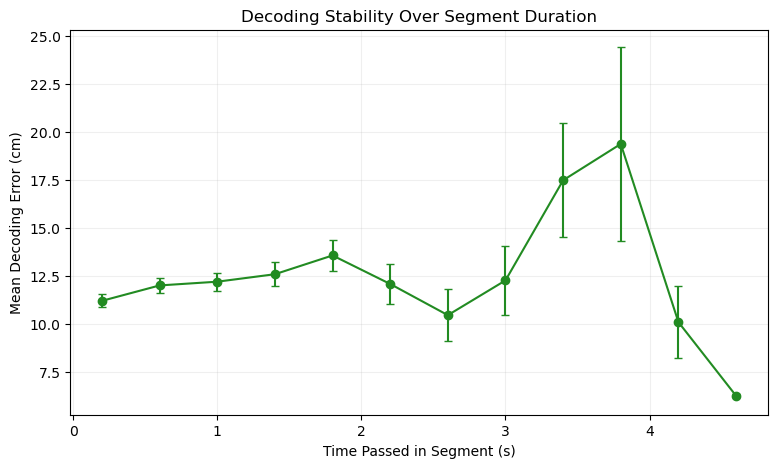

In [199]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='light')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=2 , LIGHTING="light")
plot_passed_time(segments , rat_decode , dist_step=1)


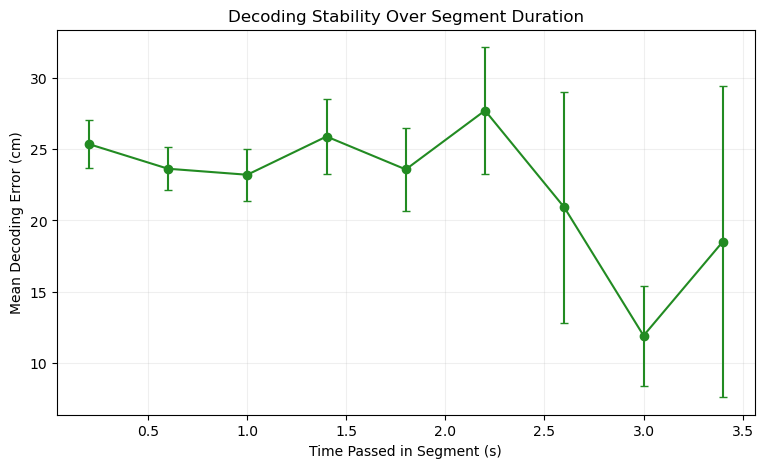

In [196]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='dark')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=2 , LIGHTING="dark")
plot_passed_time(segments , rat_decode , dist_step=5)

# traveled space plots

In [8]:
def get_error_vs_distance_traveled(segments,  rat_decode, dist_step=8.0):
    all_dists = []
    all_errors = []

    for seg in segments:
        s, e = int(seg[0]), int(seg[1])
        
        # 1. Decode the segment
        dec = rat_decode.decode_segment_adaptive(seg , dist_step = dist_step)
        if len(dec) == 0: continue

        # 2. Calculate cumulative distance for the WHOLE segment trajectory
        seg_x, seg_y = rat_decode.x[s:e], rat_decode.y[s:e]
        dx = np.diff(seg_x, prepend=seg_x[0])
        dy = np.diff(seg_y, prepend=seg_y[0])
        dr = np.sqrt(dx**2 + dy**2)
        cum_dist_full = np.cumsum(np.nan_to_num(dr))
        t_seg = rat_decode.t[s:e]

        # 3. Interpolate distance at the decoding midpoints (dec[:, 0])
        dist_at_windows = np.interp(dec[:, 0], t_seg, cum_dist_full)
        
        # 4. Error calculation
        err = np.sqrt((dec[:, 1] - dec[:, 3])**2 + (dec[:, 2] - dec[:, 4])**2)
        
        all_dists.extend(dist_at_windows)
        all_errors.extend(err)
        
    return np.array(all_dists), np.array(all_errors)

# def plot_traveled_space(segments,  rat_decode, dist_step=8.0):
#     dist_vals, err_vals = get_error_vs_distance_traveled(segments, rat_decode, dist_step=dist_step)

#     # Binning by distance (e.g., every 5 cm)
#     d_bins = np.arange(0, np.percentile(dist_vals, 95), 5.0) 
#     bin_centers = 0.5 * (d_bins[:-1] + d_bins[1:])
#     bin_means, bin_sem = [], []

#     for i in range(len(d_bins)-1):
#         mask = (dist_vals >= d_bins[i]) & (dist_vals < d_bins[i+1])
#         if np.any(mask):
#             bin_means.append(np.mean(err_vals[mask]))
#             bin_sem.append(np.std(err_vals[mask]) / np.sqrt(np.sum(mask)))
#         else:
#             bin_means.append(np.nan); bin_sem.append(np.nan)

#     plt.figure(figsize=(9, 5))
#     plt.errorbar(bin_centers, bin_means, yerr=bin_sem, fmt='-s', color='darkorange', ecolor='gray', capsize=2)
#     plt.xlabel('Cumulative Distance Traveled in Segment (cm)')
#     plt.ylabel('Mean Decoding Error (cm)')
#     plt.title('Decoding Performance vs. Path Distance')
#     plt.grid(True, which='both', linestyle='--', alpha=0.5)
#     plt.show()



def plot_traveled_space(segments, rat_decode, dist_step=8.0):
    dist_vals, err_vals = get_error_vs_distance_traveled(segments, rat_decode, dist_step=dist_step)

    # 1. Binning by distance (e.g., every 5 cm)
    d_bins = np.arange(0, np.percentile(dist_vals, 95), 5.0) 
    bin_centers = 0.5 * (d_bins[:-1] + d_bins[1:])
    
    bin_means, bin_sem, bin_counts = [], [], []

    for i in range(len(d_bins)-1):
        mask = (dist_vals >= d_bins[i]) & (dist_vals < d_bins[i+1])
        count = np.sum(mask)
        bin_counts.append(count)
        
        if count > 0:
            bin_means.append(np.mean(err_vals[mask]))
            bin_sem.append(np.std(err_vals[mask]) / np.sqrt(count))
        else:
            bin_means.append(np.nan)
            bin_sem.append(np.nan)

    # 2. Create the figure and the first axis (Error)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Error Line (Primary Y-axis)
    ax1.errorbar(bin_centers, bin_means, yerr=bin_sem, fmt='-s', 
                 color='darkorange', ecolor='gray', capsize=3, lw=2, label='Mean Error')
    ax1.set_xlabel('Cumulative Distance Traveled in Segment (cm)', fontsize=12)
    ax1.set_ylabel('Mean Decoding Error (cm)', color='darkorange', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='darkorange')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # 3. Create the second axis (Sample Count)
    ax2 = ax1.twinx()
    # Plot Sample Count Bars (Secondary Y-axis)
    # width matches the bin size (5.0) with a slight gap for aesthetics
    ax2.bar(bin_centers, bin_counts, width=4.0, alpha=0.15, color='gray', label='Sample Count')
    ax2.set_ylabel('Number of Windows (Sample Count)', color='gray', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='gray')

    plt.title(f'Decoding Performance & Data Density vs. Path Distance (step={dist_step}cm)', fontsize=14)
    fig.tight_layout()
    plt.show()

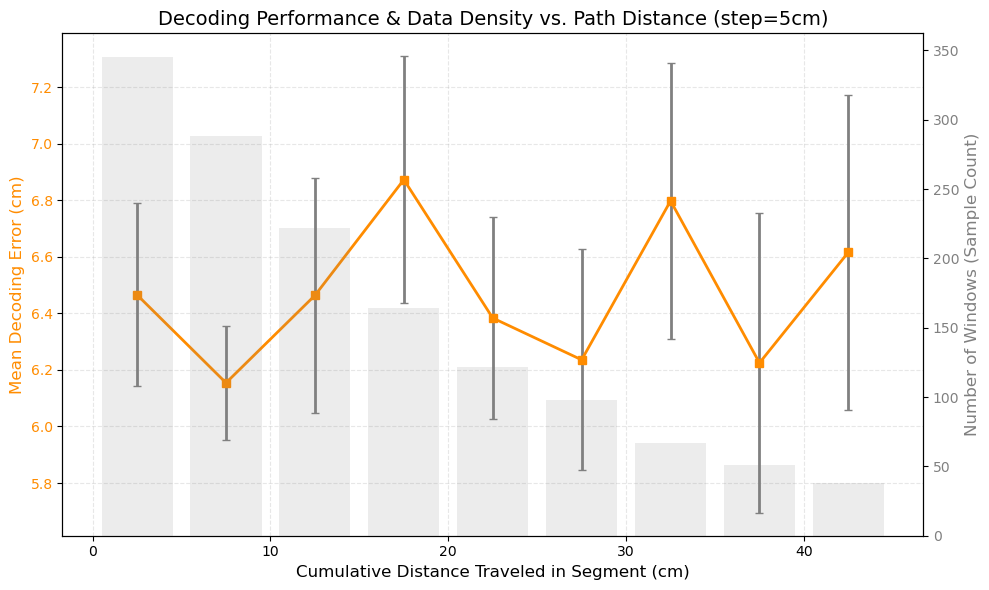

In [9]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='light')
segments_rat = rat.segments
rat_decode = DecoderMLE(RAT_ID=2 , LIGHTING="light")
plot_traveled_space(segments_rat , rat_decode , dist_step= 5)

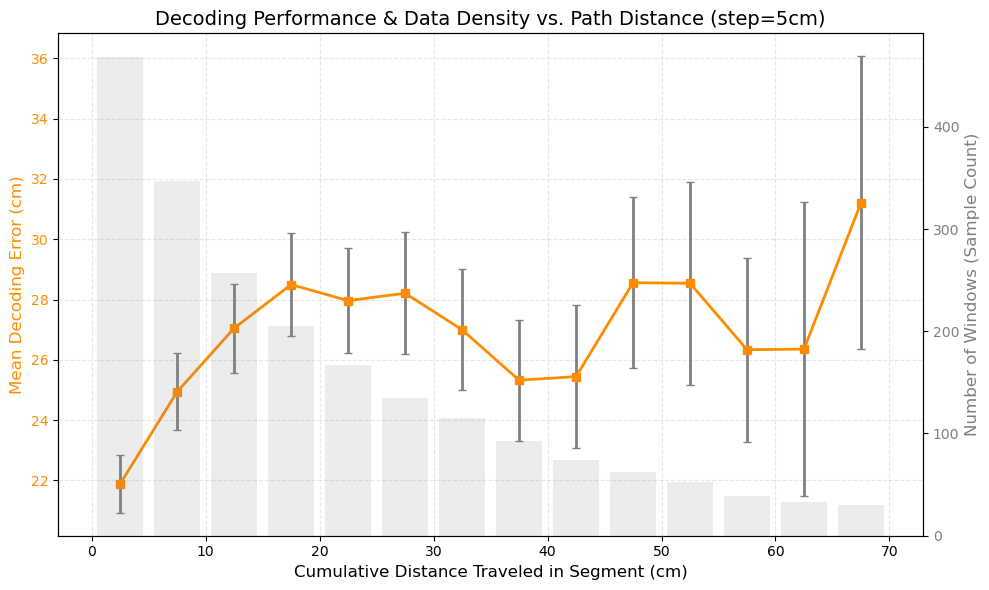

In [10]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='dark')
segments_rat = rat.segments
rat_decode = DecoderMLE(RAT_ID=2 , LIGHTING="dark")
plot_traveled_space(segments_rat , rat_decode , dist_step= 5)

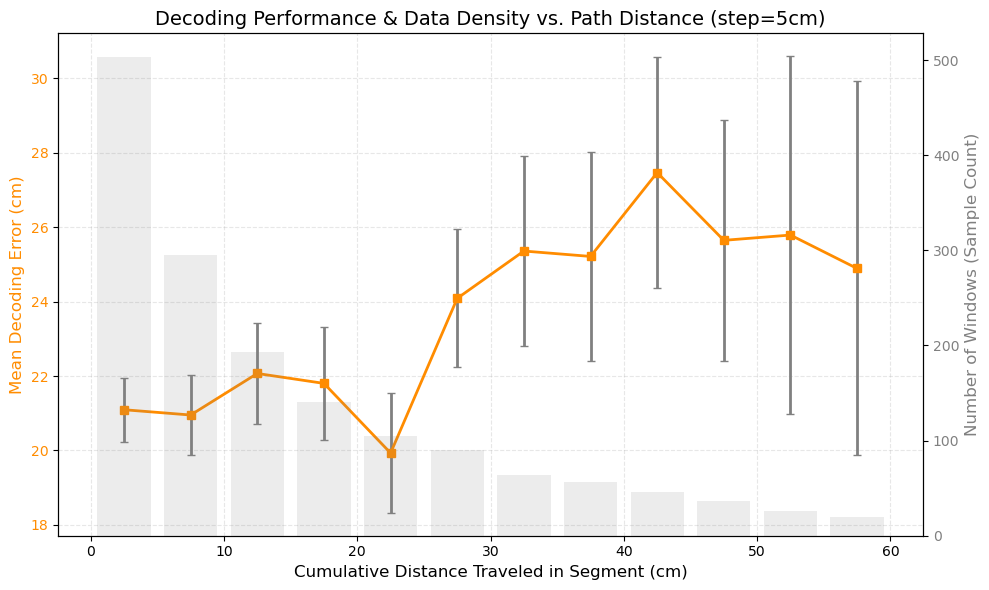

In [12]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=3 , LIGHTING='dark')
segments_rat = rat.segments
rat_decode = DecoderMLE(RAT_ID=3 , LIGHTING="dark")
plot_traveled_space(segments_rat , rat_decode , dist_step= 5)

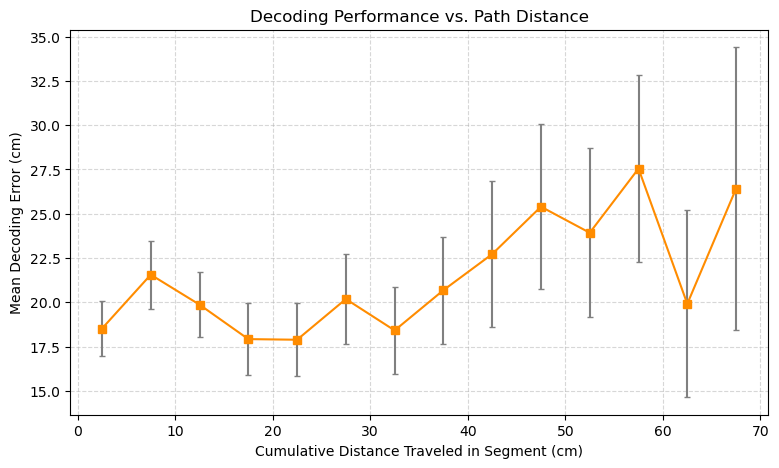

In [206]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=1 , LIGHTING='dark')
segments_ = rat.segments
rat_decode = DecoderMLE(RAT_ID=1 , LIGHTING="dark")
plot_traveled_space(segments , rat_decode , dist_step= 5)

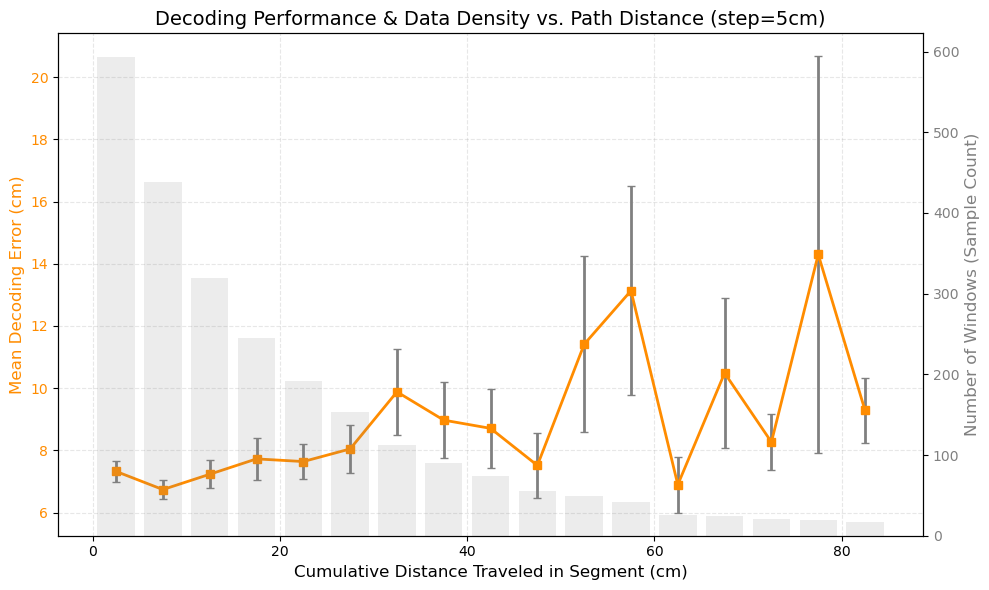

In [13]:
rat = TrajectorySegments(edge_margin= 0 , arena_radius= 75 , RAT_ID=3 , LIGHTING='light')
segments_rat = rat.segments
rat_decode = DecoderMLE(RAT_ID=3 , LIGHTING="light")
plot_traveled_space(segments_rat , rat_decode , dist_step= 5)

In [42]:
# segments : [s, e, t[s], t[e], duration)]
durations = [seg[4] for seg in segments]
# plt.hist(durations)
np.min(durations) , np.max(durations) , np.mean(durations) , np.median(durations)

(np.float64(0.50787668933026),
 np.float64(4.933096198059957),
 np.float64(1.2900566281295716),
 np.float64(1.1164910988900374))

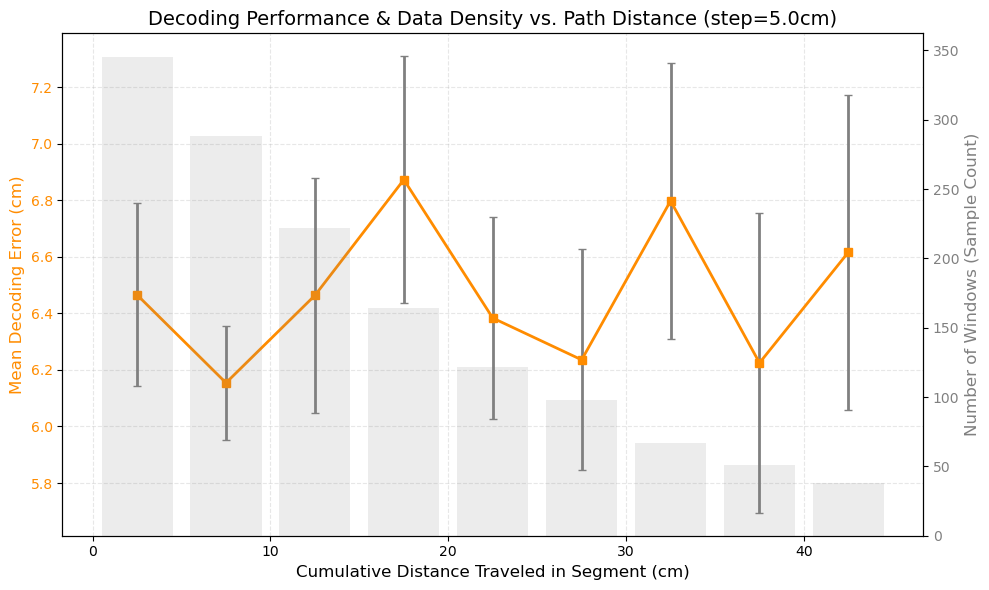

In [ ]:
from utils_PI import MakePlots
r2 = MakePlots(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='light')
r2.plot_traveled_space(dist_step=5.0 , dist_bins_ = 5.0)

# segments

In [34]:
def show_segment_statistics(segments, x, y, hd):
    """
    Calculates and plots distributions for Segment Distance, 
    Duration, Tortuosity, and Total Turning.
    """
    dist_list = []
    dur_list = []
    tortuosity_list = []
    total_turn_list = []

    for seg in segments:
        s, e = int(seg[0]), int(seg[1])
        duration = seg[4]
        
        # 1. Path Distance (Total traveled)
        dx = np.diff(x[s:e])
        dy = np.diff(y[s:e])
        path_dist = np.nansum(np.sqrt(dx**2 + dy**2))
        
        # 2. Displacement (Start to End straight line)
        displacement = np.sqrt((x[e-1] - x[s])**2 + (y[e-1] - y[s])**2)
        
        # 3. Tortuosity (Path / Displacement)
        # 1.0 = perfect straight line. Higher = more winding.
        tortuosity = path_dist / (displacement + 1e-6)
        
        # 4. Total Angular Change (Sum of absolute circular differences)
        d_hd = np.diff(hd[s:e])
        d_hd_circ = (d_hd + np.pi) % (2 * np.pi) - np.pi
        total_turn = np.nansum(np.abs(d_hd_circ)) # in Radians

        dist_list.append(path_dist)
        dur_list.append(duration)
        tortuosity_list.append(tortuosity)
        total_turn_list.append(total_turn)

    # Convert to arrays for plotting
    stats = {
        'Distance (cm)': np.array(dist_list),
        'Duration (s)': np.array(dur_list),
        'Tortuosity (ratio)': np.array(tortuosity_list),
        'Total Turning (rad)': np.array(total_turn_list)
    }

    # --- Plotting ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, (label, data) in enumerate(stats.items()):
        # Remove NaNs or Infs for clean histograms
        clean_data = data[np.isfinite(data)]
        
        axes[i].hist(clean_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].axvline(np.mean(clean_data), color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {np.mean(clean_data):.2f}')
        axes[i].set_title(f'Distribution of {label}')
        axes[i].set_xlabel(label)
        axes[i].set_ylabel('Frequency')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"Total Segments Analyzed: {len(segments)}")
    print(f"Mean Path Length: {np.mean(dist_list):.2f} cm")
    print(f"Mean Tortuosity: {np.mean(tortuosity_list):.2f}")

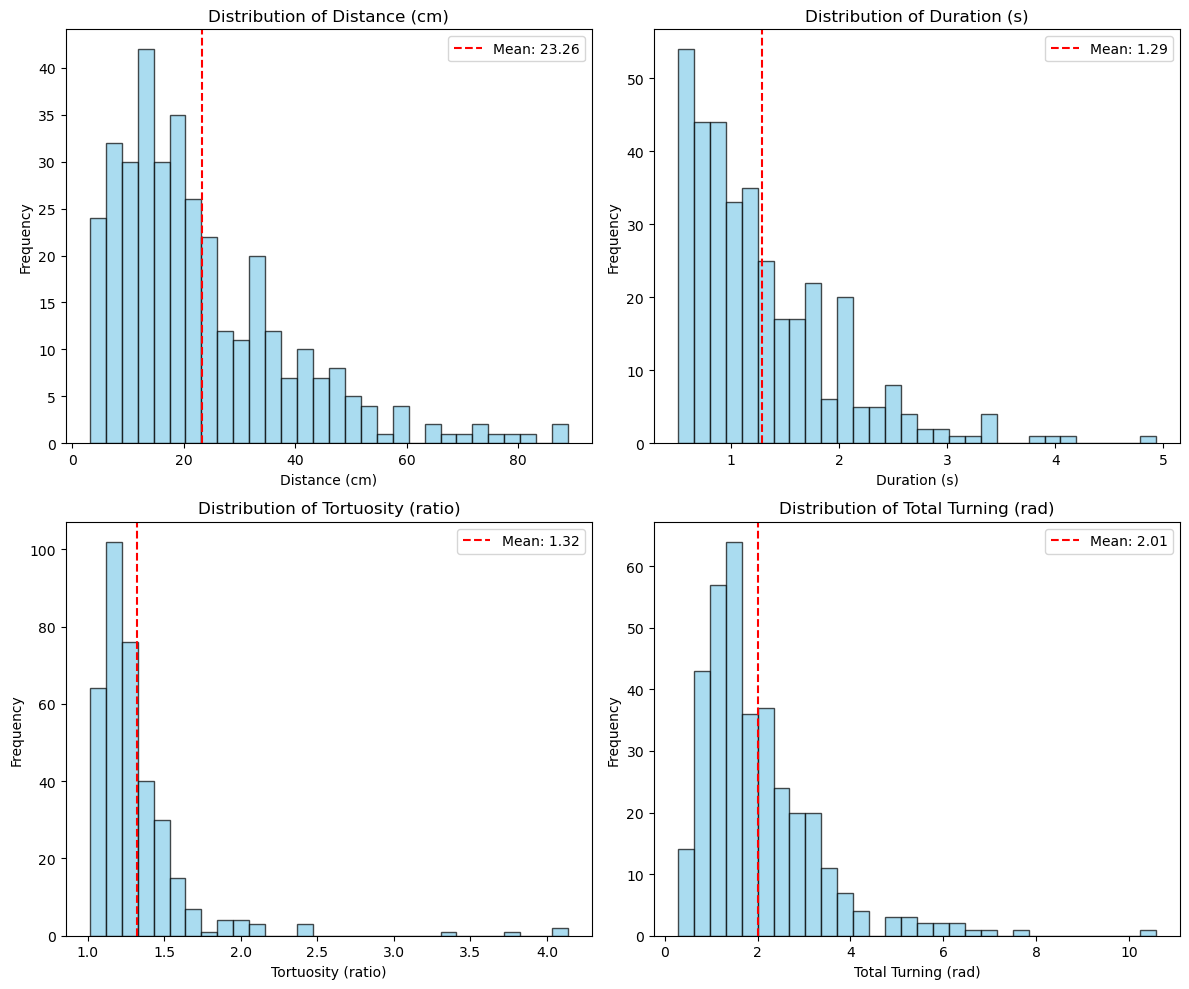

Total Segments Analyzed: 353
Mean Path Length: 23.26 cm
Mean Tortuosity: 1.32


In [37]:
rat = TrajectorySegments(edge_margin= 15 , arena_radius= 75 , RAT_ID=2 , LIGHTING='light')
segments_rat = rat.segments
rat_decode = DecoderMLE(RAT_ID=2 , LIGHTING="light")

show_segment_statistics(segments_rat ,rat_decode.x , rat_decode.y , rat_decode.hd )